In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({'figure.figsize': (12, 6),'figure.dpi':120})

In [3]:
orders = pd.read_csv(
    "../data/cleaned/cleaned_orders.csv",
    parse_dates=["created_at"]
)

order_items = pd.read_csv(
    "../data/cleaned/cleaned_order_items.csv",
    parse_dates=["created_at"]
)

order_item_refunds = pd.read_csv(
    "../data/cleaned/cleaned_order_item_refunds.csv",
    parse_dates=["created_at"]
)

products = pd.read_csv(
    "../data/cleaned/cleaned_products.csv",
    parse_dates=["created_at"]
)

website_sessions = pd.read_csv(
    "../data/cleaned/cleaned_website_sessions.csv",
    parse_dates=["created_at"]
)

website_pageviews = pd.read_csv(
    "../data/cleaned/cleaned_website_pageviews.csv",
    parse_dates=["created_at"]
)

In [4]:
import os

os.makedirs("../reports/figures", exist_ok=True)

# Orders

In [5]:
display(orders.head())

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,year,month,day,hour,day_name
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012,3,19,10,Monday
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012,3,19,19,Monday
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012,3,20,6,Tuesday
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012,3,20,9,Tuesday
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012,3,20,11,Tuesday


In [9]:
print(f"Total Revenue  : {orders['price_usd'].sum():,.2f}")
print(f"Average Revenue: {orders['price_usd'].mean():.2f}")

Total Revenue  : 1,938,509.75
Average Revenue: 59.99


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_17820\1439553316.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=revenue_by_year_orders, x='year', y='price_usd', palette='viridis')


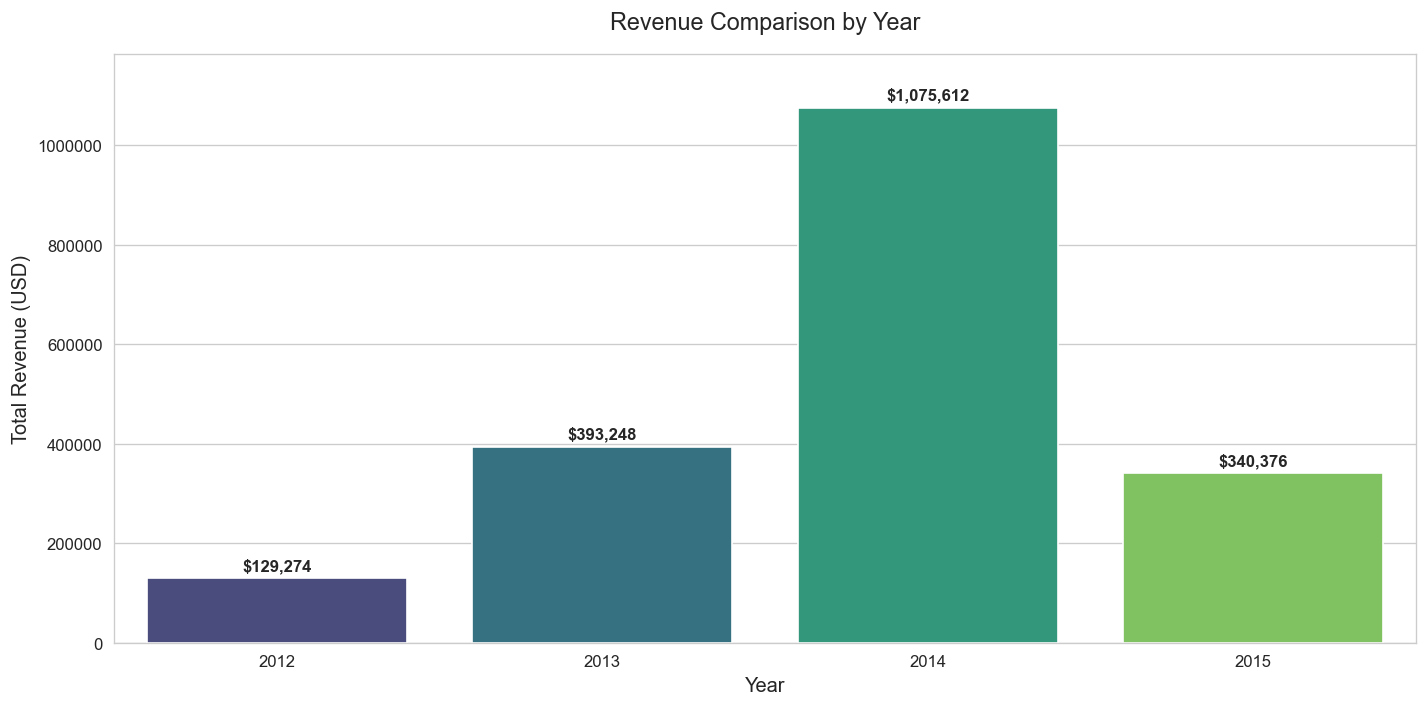

In [18]:
revenue_by_year_orders = orders.groupby('year')['price_usd'].sum().reset_index()
sns.set_style("whitegrid")
ax = sns.barplot(data=revenue_by_year_orders, x='year', y='price_usd', palette='viridis')
plt.ticklabel_format(style='plain', axis='y')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"${height:,.0f}", 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', 
                fontweight='bold')

plt.title('Revenue Comparison by Year', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.ylim(0, revenue_by_year_orders['price_usd'].max() * 1.1)
plt.tight_layout()
plt.savefig('../reports/figures/revenue_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Biểu đồ Doanh thu theo Năm (Revenue Comparison by Year)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột đứng (Bar chart) có hiển thị nhãn giá trị (Data labels).
* **Tiêu đề:** Revenue Comparison by Year (So sánh doanh thu theo năm).
* **Trục tung (Y-axis):** Total Revenue (USD) - Tổng doanh thu bằng đơn vị đô la Mỹ.
* **Trục hoành (X-axis):** Year - Giai đoạn 4 năm từ 2012 đến 2015.

---

## 2. Bảng Số liệu Chi tiết & Tăng trưởng

| Năm | Doanh thu (USD) | Tỷ lệ tăng trưởng so với năm trước (%) | Trạng thái |
| :--- | :--- | :--- | :--- |
| **2012** | $129,274 | — | Khởi đầu (Thấp nhất) |
| **2013** | $393,248 | +204.2% | Tăng trưởng mạnh |
| **2014** | $1,075,612 | +173.5% | Đạt đỉnh (Peak) |
| **2015** | $340,376 | -68.4% | Sụt giảm nghiêm trọng |

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Giai đoạn Bùng nổ (2012 - 2014)
* **Tốc độ tăng trưởng thần tốc:** Chỉ trong vòng 2 năm, doanh thu đã tăng từ $129,274 lên $1,075,612 (tức là tăng gấp **8.3 lần** so với năm doanh thu mốc 2012).
* **Sức bật từ năm 2013:** Năm 2013 ghi nhận mức tăng trưởng phần trăm cao nhất (+204.2%), tạo tiền đề cho năm 2014 vượt mốc 1 triệu USD doanh thu.
* **Đánh giá:** Doanh nghiệp đã có một giai đoạn thâm nhập thị trường hoặc mở rộng quy mô cực kỳ thành công. Các sản phẩm/dịch vụ cốt lõi đáp ứng rất tốt nhu cầu thị trường tại thời điểm này.

### Sự Suy giảm Đột ngột (Năm 2015)
* **Lao dốc mạnh:** Doanh thu năm 2015 sụt giảm tới **68.4%** so với đỉnh năm 2014, mất đi khoảng $735,236 và lùi về mức còn thấp hơn cả năm 2013 ($340,376 so với $393,248).
* **Các giả định cần đặt ra:**
  * **Vấn đề kỹ thuật/Dữ liệu:** Đây có thể là dữ liệu chưa đầy đủ của năm 2015 (ví dụ: dữ liệu chỉ mới tính đến Quý 1 hoặc Quý 2 năm 2015).
  * **Vấn đề vận hành:** Nếu dữ liệu đã đủ, doanh nghiệp có thể đã mất đi một hoặc vài hợp đồng/khách hàng lớn mang tính quyết định, hoặc gặp khủng hoảng nghiêm trọng về chuỗi cung ứng/giao nhận.

---

## 4. Đề xuất & Định hướng Hành động (Recommendations)

1. **Xác minh mốc thời gian của dữ liệu năm 2015:** Bước đầu tiên và quan trọng nhất là kiểm tra xem dữ liệu năm 2015 đã được tổng kết trọn vẹn 12 tháng hay chưa. Nếu chưa, cần bổ sung phần chú thích (e.g., "YTD 2015" hoặc "Tính đến tháng X/2015") vào biểu đồ để tránh gây hiểu lầm cho người xem.
2. **Giải mã "Công thức thành công" năm 2014:** Tiến hành phân tích sâu (Drill-down) dữ liệu năm 2014 theo danh mục sản phẩm, nhóm khách hàng và kênh phân phối để xác định rõ yếu tố nào đã thúc đẩy doanh thu vượt ngưỡng triệu đô.
3. **Phân tích nguyên nhân sụt giảm:** Trong trường hợp dữ liệu 2015 là chính xác và trọn vẹn, cần thực hiện phân tích ma trận để tìm ra nguyên nhân cốt lõi (do thị trường bão hòa, đối thủ cạnh tranh mới xuất hiện, hay do chính sách giá thay đổi).

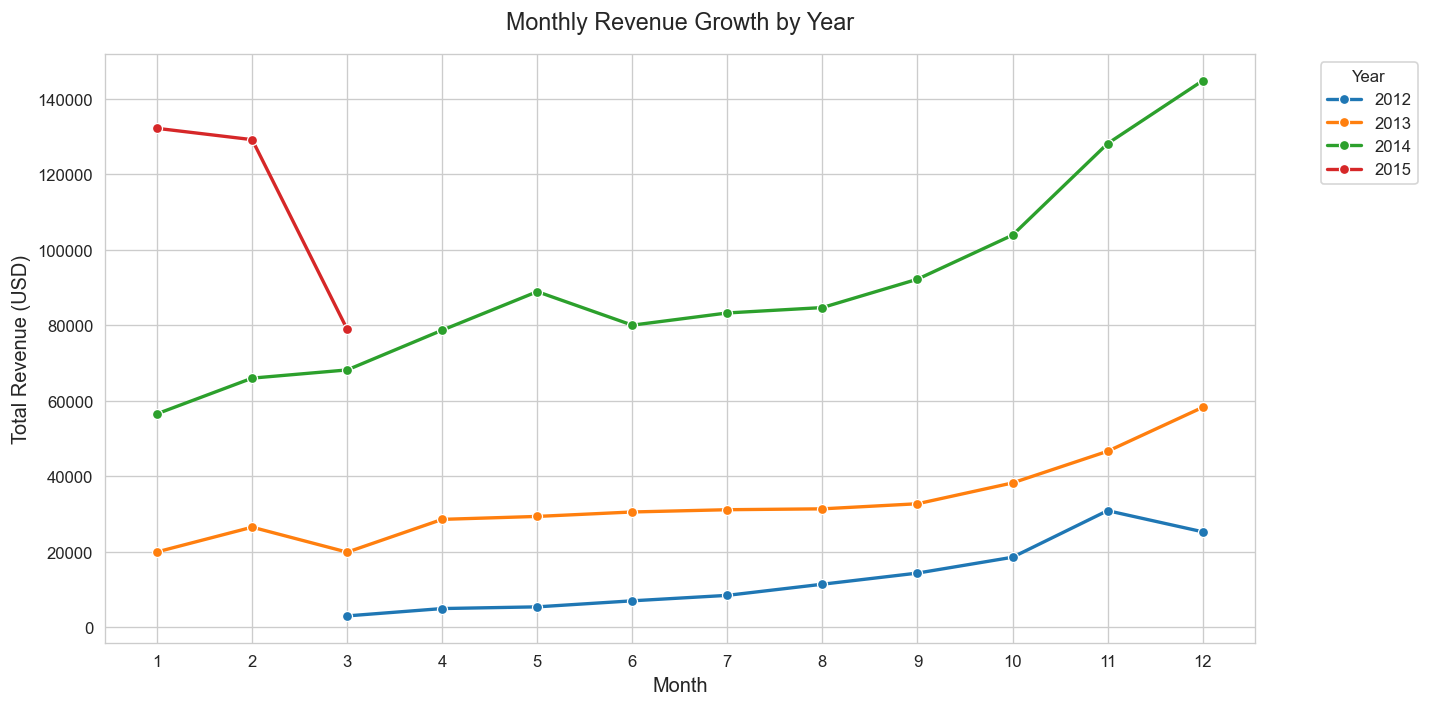

In [20]:
monthly_growth_orders = orders.groupby(['year', 'month'])['price_usd'].sum().reset_index()
sns.set_style("whitegrid")
ax = sns.lineplot(data=monthly_growth_orders, x='month', y='price_usd', hue='year', marker='o', palette='tab10', linewidth=2)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(range(1, 13))
plt.title('Monthly Revenue Growth by Year', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../reports/figures/monthly_growth_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Xu hướng Doanh thu Hàng tháng theo Năm (Monthly Revenue Growth by Year)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ đường (Line Chart).
* **Tiêu đề:** Monthly Revenue Growth by Year (Tăng trưởng doanh thu hàng tháng theo năm).
* **Trục tung (Y-axis):** Total Revenue (USD) - Tổng doanh thu bằng USD.
* **Trục hoành (X-axis):** Month - Các tháng trong năm (từ tháng 1 đến tháng 12).
* **Chú giải (Legend):** Thể hiện 4 đường dữ liệu tương ứng với 4 năm: 2012 (Xanh dương), 2013 (Cam), 2014 (Xanh lá), và 2015 (Đỏ).

---

## 2. Các Quan sát Chính (Key Observations)

* **Sự tăng trưởng liên tục qua các năm:** Từ 2012 đến 2014, đường xu hướng của năm sau luôn nằm trên năm trước, minh chứng cho sự mở rộng quy mô ổn định.
* **Đặc tính mùa vụ (Seasonality):** Dữ liệu của các năm trọn vẹn (2012, 2013, 2014) đều cho thấy một xu hướng chung:
  * Doanh thu thường tăng chậm hoặc đi ngang ở giai đoạn giữa năm (tháng 5 đến tháng 8).
  * Doanh thu **bứt phá mạnh mẽ vào Quý 4** (tháng 10, 11, 12). Đặc biệt năm 2014, doanh thu tháng 12 đạt đỉnh hơn $140,000.
* **Dữ liệu không trọn vẹn của 2012:** Năm 2012 chỉ có dữ liệu bắt đầu từ tháng 3, cho thấy đây có thể là thời điểm doanh nghiệp mới bắt đầu ghi nhận doanh thu hoặc mới thành lập.
* **Phát hiện quan trọng về năm 2015:** Đường dữ liệu năm 2015 (màu đỏ) **chỉ có số liệu của 3 tháng đầu năm** (tháng 1, 2, 3) và kết thúc đột ngột. 

---

## 3. Nhận xét Chuyên sâu (Insights)

### Giải mã "Sự sụt giảm ảo" của năm 2015
Biểu đồ này đã giải thích hoàn toàn cho mức tổng doanh thu thấp của năm 2015 ($340,376) ở biểu đồ cột trước đó. Sự sụt giảm đó không phải do tình hình kinh doanh đi xuống, mà do **dữ liệu năm 2015 chưa được thu thập đầy đủ (mới chỉ tính hết Quý 1/2015)**. 

Nếu cộng dồn trực quan từ biểu đồ đường này: Doanh thu tháng 1 (~$132,000) + tháng 2 (~$129,000) + tháng 3 (~$79,000), tổng sẽ xấp xỉ khớp với con số $340,376.

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_17820\1864324662.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=orders, x='items_purchased', palette='viridis')


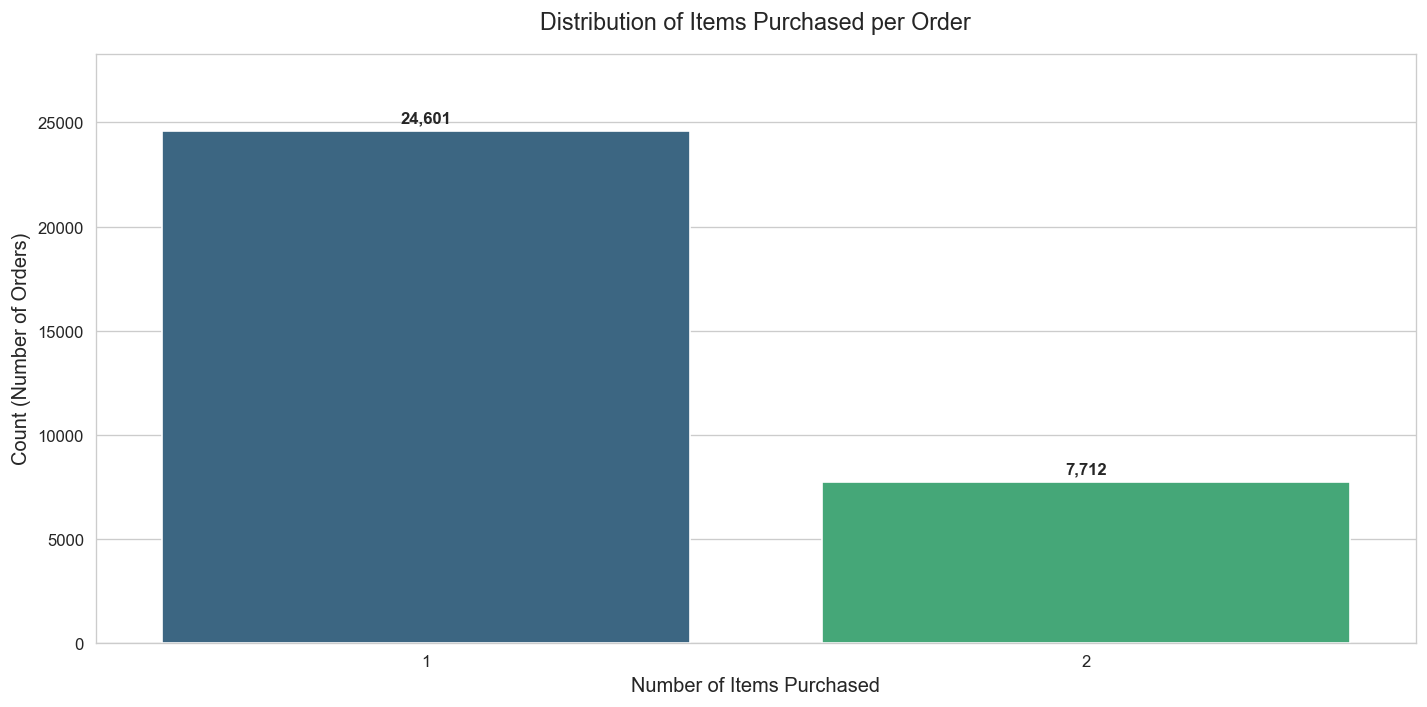

In [29]:
sns.set_style("whitegrid")
ax = sns.countplot(data=orders, x='items_purchased', palette='viridis')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:,.0f}", 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontweight='bold')
plt.title('Distribution of Items Purchased per Order', fontsize=14, pad=15)
plt.xlabel('Number of Items Purchased', fontsize=12)
plt.ylabel('Count (Number of Orders)', fontsize=12)
plt.ylim(0, orders['items_purchased'].value_counts().max() * 1.15)
plt.tight_layout()
plt.savefig('../reports/figures/items_purchased_distribution.png', bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Phân phối Số lượng Sản phẩm trên Mỗi Đơn hàng

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột (Bar chart / Countplot) thể hiện tần suất.
* **Tiêu đề:** Distribution of Items Purchased per Order (Phân phối số lượng sản phẩm được mua trên mỗi đơn hàng).
* **Trục tung (Y-axis):** Count (Number of Orders) - Số lượng đơn hàng.
* **Trục hoành (X-axis):** Number of Items Purchased - Số lượng sản phẩm khách mua trong một đơn.

---

## 2. Bảng Số liệu Chi tiết & Tỷ trọng

Tổng số lượng đơn hàng (Total Orders) trong tập dữ liệu này là: **32,313** đơn.

| Số lượng sản phẩm/đơn | Số lượng đơn hàng | Tỷ trọng (%) |
| :---: | :--- | :--- |
| **1** | 24,601 | 76.13% |
| **2** | 7,712 | 23.87% |

---

## 3. Nhận xét và Đánh giá (Insights)

### Hành vi mua sắm "nhỏ giọt" là chủ đạo
* Khách hàng có xu hướng mua lẻ từng sản phẩm một. Phần lớn các đơn hàng (hơn 76%) chỉ chứa duy nhất **1 sản phẩm**. 
* Chỉ có chưa tới 1/4 tổng số đơn hàng (khoảng 24%) là có chứa **2 sản phẩm**.

---

## 4. Đề xuất Chiến lược (Recommendations)

 **Tối ưu hóa giá trị trung bình trên mỗi đơn (AOV - Average Order Value):**
   * **Chiến lược Cross-selling (Bán chéo):** Triển khai thuật toán gợi ý hệ thống (Recommendation System) hiển thị mục "Thường được mua cùng nhau" (Frequently bought together) ngay tại trang sản phẩm hoặc trang thanh toán.
   * **Bán theo Combo/Bundle:** Tạo các gói sản phẩm giảm giá khi mua từ 2 món trở lên để khuyến khích nhóm 76% khách hàng kia tăng quy mô giỏ hàng.
   * **Miễn phí vận chuyển có điều kiện:** Đặt ngưỡng freeship cao hơn một chút so với giá trị trung bình của 1 sản phẩm để kích thích khách hàng mua thêm món thứ 2.



# Order_items

In [35]:
display(order_items.head())

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd,year,month,day,hour,day_name
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,2012,3,19,10,Monday
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,2012,3,19,19,Monday
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,2012,3,20,6,Tuesday
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,2012,3,20,9,Tuesday
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,2012,3,20,11,Tuesday


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_17820\3630289039.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=revenue_by_product, x='product_id', y='price_usd', palette='viridis')


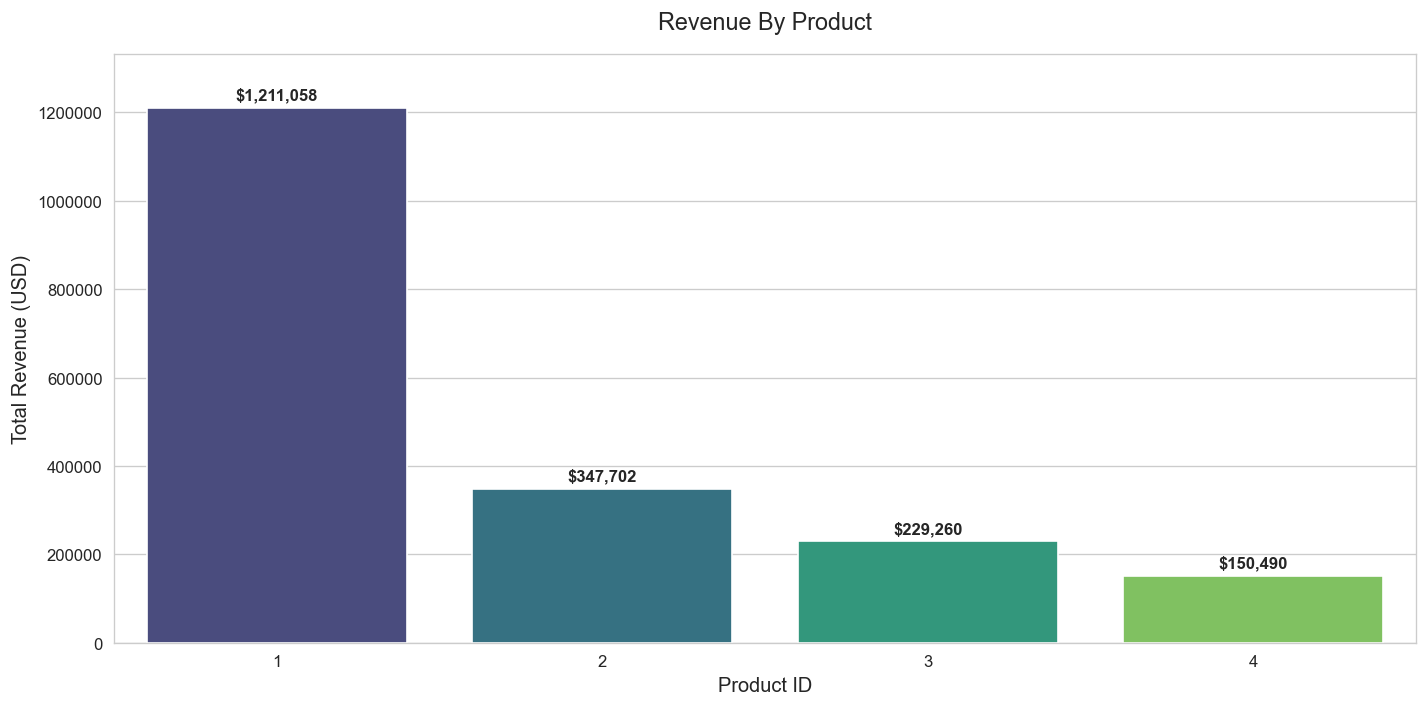

In [38]:
revenue_by_product = order_items.groupby('product_id')['price_usd'].sum().reset_index()
sns.set_style("whitegrid")
ax = sns.barplot(data=revenue_by_product, x='product_id', y='price_usd', palette='viridis')

plt.ticklabel_format(style='plain', axis='y')
for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f"${height:,.0f}", 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontweight='bold')
plt.title('Revenue By Product', fontsize=14, pad=15)
plt.xlabel('Product ID', fontsize=12) 
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.ylim(0, revenue_by_product['price_usd'].max() * 1.1)
plt.tight_layout()
plt.savefig('../reports/figures/revenue_by_product.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Doanh thu theo Sản phẩm (Revenue By Product)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột đứng (Bar chart) có hiển thị nhãn dữ liệu.
* **Tiêu đề:** Revenue By Product (Doanh thu theo từng Sản phẩm).
* **Trục tung (Y-axis):** Total Revenue (USD) - Tổng doanh thu bằng đô la Mỹ.
* **Trục hoành (X-axis):** Product ID / Name - Mã định danh và tên của 4 dòng sản phẩm.

---

## 2. Bảng Số liệu Chi tiết & Tỷ trọng Đóng góp

Tổng doanh thu của cả 4 sản phẩm đạt: **$1,938,510**.

| Product ID | Tên sản phẩm (Product Name) | Doanh thu (USD) | Tỷ trọng trên Tổng doanh thu (%) | Xếp hạng |
| :---: | :--- | :--- | :--- | :---: |
| **1** | The Original Mr. Fuzzy | $1,211,058 | ~ 62.47% | 1 |
| **2** | The Forever Love Bear | $347,702 | ~ 17.94% | 2 |
| **3** | The Birthday Sugar Panda | $229,260 | ~ 11.83% | 3 |
| **4** | The Hudson River Mini bear | $150,490 | ~ 7.76% | 4 |

---

## 3. Nhận xét và Đánh giá (Insights)

### Sản phẩm "The Original Mr. Fuzzy" (ID 1) là "Con gà đẻ trứng vàng" (Cash Cow)
* **Sự chênh lệch khổng lồ:** "The Original Mr. Fuzzy" áp đảo hoàn toàn khi mang về tới hơn 1.2 triệu USD, chiếm gần **62.5%** tổng doanh thu của toàn bộ danh mục.
* Doanh thu của riêng sản phẩm này cao gấp **3.5 lần** so với sản phẩm đứng thứ hai ("The Forever Love Bear") và vượt qua tổng doanh thu của cả 3 sản phẩm còn lại cộng lại ($727,452).
* **Lợi thế người tiên phong:** Vì đây là sản phẩm đầu tiên được ra mắt (tháng 3/2012), sản phẩm này có lợi thế lớn về mặt thời gian tích lũy doanh số và độ nhận diện thương hiệu trên thị trường.

### Khoảng cách lớn giữa các nhóm sản phẩm còn lại
* Các sản phẩm ra mắt sau bao gồm **"The Forever Love Bear" (ID 2)**, **"The Birthday Sugar Panda" (ID 3)** và **"The Hudson River Mini bear" (ID 4)** có mức doanh thu giảm dần khá đều đặn.
* Trong đó, "The Hudson River Mini bear" (ID 4) có hiệu suất thấp nhất (chỉ chiếm ~7.76% doanh thu). Điều này một phần do sản phẩm này ra mắt muộn nhất (tháng 2/2014) nên chưa có nhiều thời gian tối ưu và tích lũy doanh số như các dòng sản phẩm trước.

### Rủi ro về sự phụ thuộc sản phẩm (Concentration Risk)
* Việc doanh thu phụ thuộc quá lớn (gần 2/3) vào một sản phẩm duy nhất là "The Original Mr. Fuzzy" mang lại rủi ro vận hành cao. Nếu dòng sản phẩm này gặp sự cố về chuỗi cung ứng hoặc xu hướng thị trường thay đổi, tổng doanh thu của toàn doanh nghiệp sẽ bị ảnh hưởng nghiêm trọng.

---

## 4. Đề xuất Chiến lược (Recommendations)

1. **Bảo vệ và tối ưu hóa sản phẩm chủ lực ("The Original Mr. Fuzzy"):**
   * Đảm bảo nguồn cung và chất lượng luôn ở mức tốt nhất cho dòng sản phẩm này.
   * Phân tích sâu tệp khách hàng mua sản phẩm này để tìm ra công thức thành công và áp dụng định hướng cho các sản phẩm khác.

2. **Chiến lược Bán chéo (Cross-Selling & Bundling):**
   * Tận dụng lượng khách hàng khổng lồ từ "The Original Mr. Fuzzy" để tạo các gói combo bán kèm với "The Forever Love Bear" hoặc "The Birthday Sugar Panda" nhằm thúc đẩy doanh số cho nhóm dưới.

3. **Theo dõi tốc độ tăng trưởng của sản phẩm mới ("The Hudson River Mini bear"):**
   * Doanh thu tổng của ID 4 hiện đang thấp nhất do yếu tố thời gian ra mắt muộn. Cần bóc tách dữ liệu theo tháng để đánh giá xem sản phẩm này có tiềm năng tăng trưởng tốt hay không trước khi quyết định tăng hoặc giảm ngân sách đầu tư.

# Order_item_refund

In [40]:
display(order_item_refunds.head())

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd,year,month,day,hour,day_name
0,1,2012-04-06 11:32:43,57,57,49.99,2012,4,6,11,Friday
1,2,2012-04-13 01:09:43,74,74,49.99,2012,4,13,1,Friday
2,3,2012-04-15 07:03:48,71,71,49.99,2012,4,15,7,Sunday
3,4,2012-04-17 20:00:37,118,118,49.99,2012,4,17,20,Tuesday
4,5,2012-04-22 20:53:49,116,116,49.99,2012,4,22,20,Sunday


In [44]:
print(f"Total Refund_amount_usd: ${order_item_refunds['refund_amount_usd'].sum():,.2f}")

Total Refund_amount_usd: $85,338.69


# Website_sessions 

In [45]:
display(website_sessions.head())

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,year,month,day,hour,day_name
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2012,3,19,8,Monday
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012,3,19,8,Monday
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012,3,19,8,Monday
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012,3,19,8,Monday
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2012,3,19,9,Monday


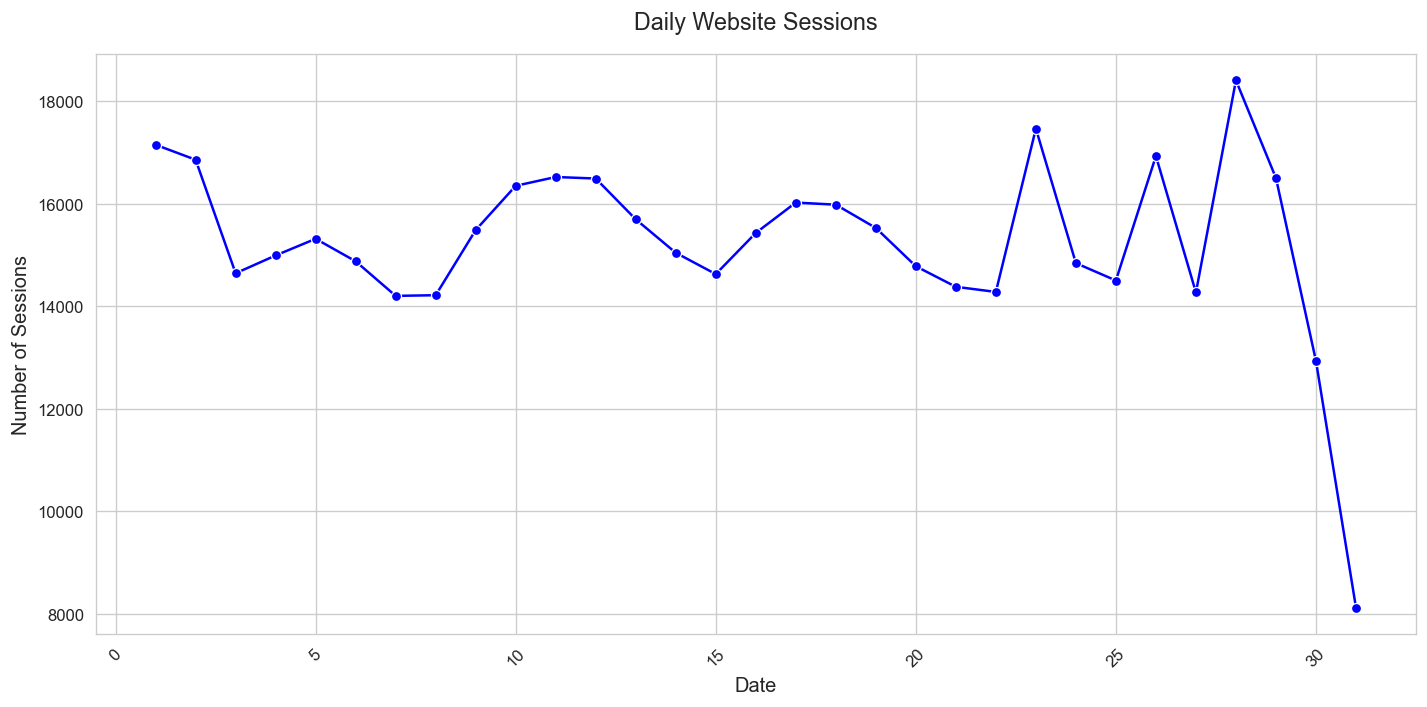

In [66]:
daily_sessions_dataset = website_sessions.groupby('day')['website_session_id'].count().reset_index()
sns.set_style("whitegrid")
sns.lineplot(data=daily_sessions_dataset, x='day', y='website_session_id', marker='o', color='blue')
plt.title('Daily Website Sessions', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/daily_sessions.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Lưu lượng Truy cập Website Hàng ngày (Daily Website Sessions)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ đường (Line chart) có điểm đánh dấu (markers).
* **Tiêu đề:** Daily Website Sessions (Số lượng phiên truy cập website mỗi ngày).
* **Trục tung (Y-axis):** Number of Sessions - Số lượng phiên truy cập (dao động từ mốc 8,000 đến trên 18,000).
* **Trục hoành (X-axis):** Date - Ngày trong tháng (thể hiện chuỗi thời gian xấp xỉ 31 ngày).

---

## 2. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Tính chu kỳ rõ rệt (Weekly Seasonality)
* Dữ liệu thể hiện một mô hình gợn sóng lặp đi lặp lại rất đều đặn. Các khoảng cách giữa các đỉnh (peaks) và đáy (troughs) diễn ra theo chu kỳ khoảng 7 ngày.
* **Đánh giá:** Điều này phản ánh rõ hành vi của người dùng thay đổi theo các ngày trong tuần. Tùy thuộc vào mô hình kinh doanh (B2B hay B2C), website này có thể thu hút lượng truy cập cao vào các ngày làm việc trong tuần (Weekdays) và giảm xuống vào dịp cuối tuần (Weekends), hoặc ngược lại.

### Sự ổn định trong phần lớn thời gian
* Từ ngày 1 đến ngày 28, lưu lượng truy cập duy trì ở mức khá tốt và tương đối ổn định. Lượng sessions chủ yếu dao động trong biên độ từ 14,000 đến 17,000 phiên/ngày.
* Website đạt **đỉnh lưu lượng (Peak)** vào khoảng ngày 28 với hơn **18,000 phiên truy cập**, có thể do hiệu ứng của một chiến dịch marketing hoặc sự kiện đặc biệt nào đó.

### Sự sụt giảm bất thường (Anomaly) vào cuối tháng
* Điểm đáng lưu tâm nhất của toàn bộ biểu đồ là **cú lao dốc cực mạnh vào hai ngày cuối cùng** của chuỗi dữ liệu (ngày 30 và 31).
* Lượng truy cập rớt thẳng đứng từ mức đỉnh >18,000 (ngày 28) xuống chỉ còn khoảng ~13,000 (vào ngày 30) và "chạm đáy" ở mức **~8,100 (vào ngày 31)**. Đây là mức thấp nhất trong toàn bộ chu kỳ quan sát (giảm hơn 50% so với mức trung bình).

---

## 3. Đề xuất & Định hướng Hành động (Recommendations)

1. **Điều tra khẩn cấp "cú sốc" dữ liệu cuối tháng (Root-cause Analysis):**
   * **Về mặt Kỹ thuật:** Cần kiểm tra lại ngay tình trạng hoạt động của server (có xảy ra downtime không?) và các công cụ tracking (như Google Analytics tag có bị rớt/đứt gãy mã theo dõi trong 2 ngày đó không?).
   * **Về mặt Kinh doanh:** Nếu dữ liệu tracking là chuẩn xác, cần họp với các bộ phận liên quan để làm rõ nguyên nhân (Website bị lỗi thanh toán, hết hạn chương trình khuyến mãi lớn, hay do bị chặn truy cập từ một nguồn traffic chính?).

2. **Tận dụng Tính chu kỳ tuần (Leveraging Seasonality):**
   * **Marketing:** Lên lịch tung ra các chiến dịch quảng cáo, gửi Email Marketing hoặc Push Notification vào những ngày đang đà tăng trưởng (tiến về đỉnh) để tối đa hóa tỷ lệ chuyển đổi (Conversion Rate).
   * **Vận hành/IT:** Tuyệt đối tránh lên lịch bảo trì hệ thống (Maintenance) hoặc cập nhật tính năng mới vào những ngày có lưu lượng cao. Nên dời lịch các công việc này vào những ngày traffic chạm đáy (troughs) để giảm thiểu rủi ro ảnh hưởng đến người dùng.

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_17820\4204872574.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=website_sessions, y='utm_source', palette='viridis', order=website_sessions['utm_source'].value_counts().index)


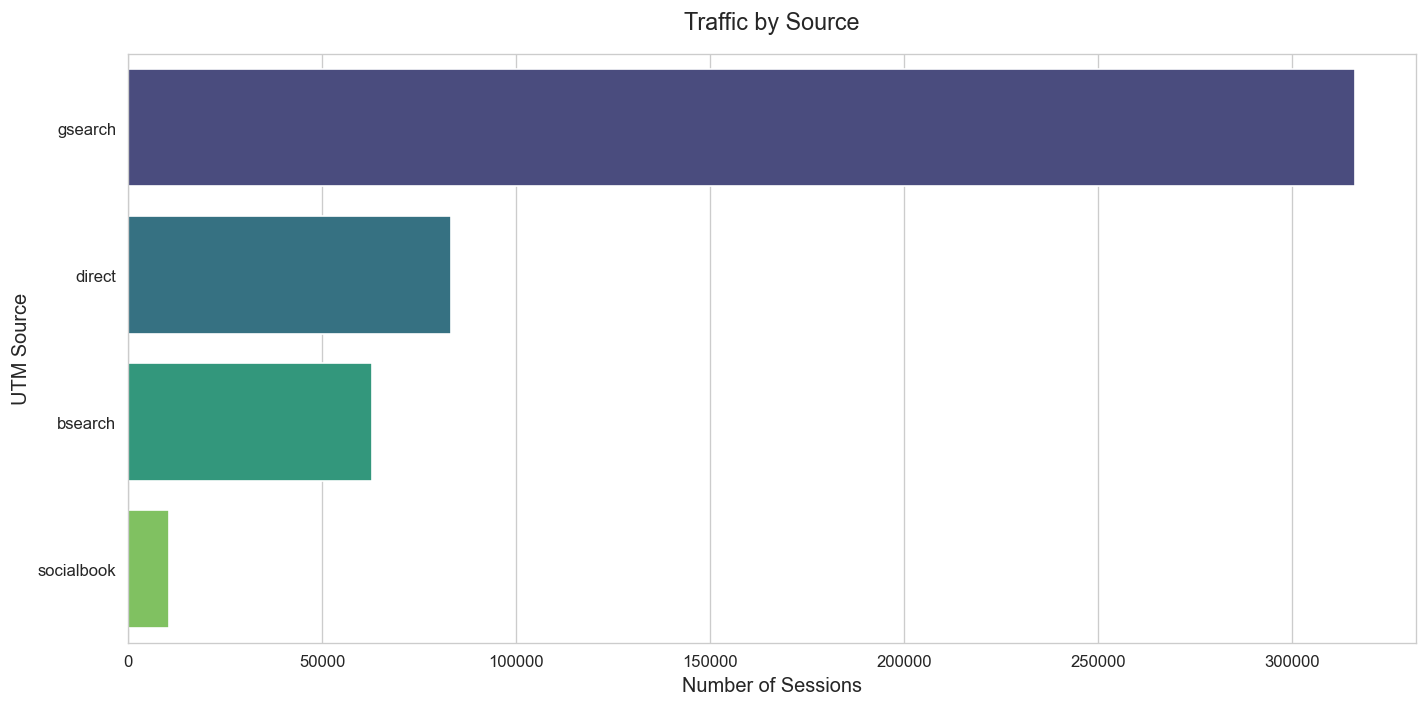

In [65]:

sns.set_style("whitegrid")
sns.countplot(data=website_sessions, y='utm_source', palette='viridis', order=website_sessions['utm_source'].value_counts().index)
plt.title('Traffic by Source', fontsize=14, pad=15)
plt.xlabel('Number of Sessions', fontsize=12)
plt.ylabel('UTM Source', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/traffic_by_source.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Nguồn Lưu lượng Truy cập (Traffic by Source)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột ngang (Horizontal Bar chart).
* **Tiêu đề:** Traffic by Source (Lưu lượng truy cập phân bổ theo Nguồn).
* **Trục hoành (X-axis):** Number of Sessions - Số lượng phiên truy cập.
* **Trục tung (Y-axis):** UTM Source - Mã nguồn chiến dịch tiếp thị (bao gồm: gsearch, direct, bsearch, socialbook).

---

## 2. Số liệu Ước lượng & Tỷ trọng

Dựa trên trục hoành, chúng ta có thể ước lượng các số liệu như sau:

| Nguồn (UTM Source) | Số lượng Sessions (Ước lượng) | Xếp hạng |
| :--- | :--- | :---: |
| **gsearch** (Google Search) | ~ 315,000 | 1 |
| **direct** (Truy cập trực tiếp) | ~ 85,000 | 2 |
| **bsearch** (Bing Search) | ~ 60,000 | 3 |
| **socialbook** (Mạng xã hội) | ~ 10,000 | 4 |

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Sự thống trị tuyệt đối của "gsearch"
* **"gsearch"** (rất có thể là Google Search / Google Ads) là kênh mang lại nguồn lưu lượng khổng lồ và áp đảo hoàn toàn các kênh còn lại (vượt mức 300,000 phiên).
* **Đánh giá:** Website đang phụ thuộc rất lớn vào công cụ tìm kiếm này. Các chiến dịch SEO (Tối ưu hóa công cụ tìm kiếm) hoặc SEM (Quảng cáo trả phí) trên Google đang hoạt động cực kỳ hiệu quả và đóng vai trò là "xương sống" cho traffic của toàn bộ trang web.

### Nhận diện thương hiệu tốt thông qua kênh "direct"
* Lượng truy cập **"direct"** (khách hàng gõ trực tiếp URL vào trình duyệt hoặc dùng bookmark) đứng ở vị trí thứ hai với khoảng 85,000 phiên.
* **Đánh giá:** Đây là một tín hiệu rất tích cực. Nó cho thấy doanh nghiệp đã xây dựng được độ nhận diện thương hiệu tốt, sở hữu một tệp khách hàng trung thành thường xuyên quay lại website mà không cần thông qua các công cụ tìm kiếm hay quảng cáo.

### Khoảng trống lớn trên Mạng xã hội ("socialbook")
* Nguồn traffic từ **"socialbook"** (đại diện cho các nền tảng mạng xã hội) rất khiêm tốn, chỉ đạt khoảng 10,000 phiên (chưa tới 1/30 so với gsearch).
* **Đánh giá:** Các chiến dịch truyền thông trên mạng xã hội hiện tại chưa mang lại hiệu quả trong việc thu hút người dùng nhấp vào liên kết để truy cập website.

---

## 4. Đề xuất Chiến lược (Recommendations)

1. **Bảo vệ "Thành trì" gsearch:**
   * Vì đây là kênh sống còn, cần liên tục theo dõi thứ hạng từ khóa (SEO) và tối ưu hóa chi phí chạy quảng cáo (CPC/CPA) để đảm bảo không bị đối thủ cạnh tranh cướp mất vị thế trên trang kết quả tìm kiếm.

2. **Khai thác tối đa tệp khách hàng direct:**
   * Lượng khách hàng truy cập trực tiếp là những người đã có sẵn sự tin tưởng. Cần tối ưu hóa giao diện (UI/UX) và cá nhân hóa trải nghiệm cho nhóm này (ví dụ: hiển thị các sản phẩm họ đã xem, gợi ý mua lại) để tăng tỷ lệ chuyển đổi (Conversion Rate).

3. **Tái cấu trúc chiến lược Mạng xã hội (Social Media):**
   * Cần đánh giá lại kênh "socialbook". Việc traffic thấp là do ngân sách phân bổ ít, do nội dung không đủ hấp dẫn để người dùng click, hay do đặc thù sản phẩm không phù hợp để bán qua mạng xã hội? Nếu tiềm năng vẫn còn, cần thay đổi cách làm content và target lại đối tượng khách hàng trên nền tảng này.

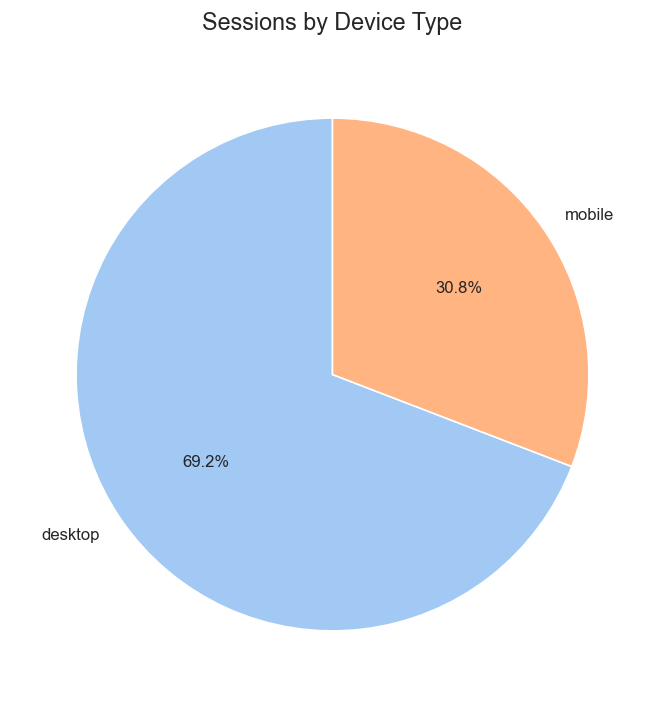

In [64]:
device_counts_dataset = website_sessions['device_type'].value_counts()
plt.pie(device_counts_dataset, labels=device_counts_dataset.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Sessions by Device Type', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/device_type_pie.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Phân bổ Phiên truy cập theo Thiết bị (Sessions by Device Type)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ tròn (Pie chart).
* **Tiêu đề:** Sessions by Device Type (Phiên truy cập phân bổ theo Loại thiết bị).
* **Các thành phần (Categories):** Bao gồm 2 nhóm thiết bị chính là `desktop` (Máy tính bàn/Laptop) và `mobile` (Điện thoại di động).

---

## 2. Số liệu Chi tiết

| Loại thiết bị | Tỷ trọng (%) | Xếp hạng |
| :--- | :---: | :---: |
| **Desktop** | 69.2% | 1 |
| **Mobile** | 30.8% | 2 |

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Sự áp đảo của Desktop
* Nhóm thiết bị **Desktop** đang chiếm ưu thế tuyệt đối với hơn 2/3 tổng lưu lượng truy cập (69.2%), cao gấp hơn 2 lần so với nền tảng Mobile. 
* Điều này cho thấy phần lớn khách hàng có thói quen hoặc sở thích tìm kiếm, duyệt sản phẩm và (rất có thể là) thực hiện mua hàng trên các thiết bị có màn hình lớn.

### Phân tích Hành vi Người dùng (Dựa trên bối cảnh)
* **Giả thuyết 1 - Đặc thù sản phẩm hoặc Bối cảnh mua sắm:** Trong bối cảnh bán lẻ thông thường hiện nay (đặc biệt là B2C), xu hướng *Mobile-first* thường chiếm ưu thế. Tuy nhiên, việc trang web của bạn có traffic Desktop cao đến vậy có thể ngụ ý rằng khách hàng thường tìm kiếm và mua đồ (ví dụ: mua gấu bông làm quà tặng) trong giờ hành chính, khi họ đang ngồi làm việc tại văn phòng.
* **Giả thuyết 2 - Rào cản kỹ thuật trên Mobile:** Một khả năng khác cần lưu tâm là trải nghiệm người dùng (UI/UX) trên phiên bản di động của website chưa thực sự tốt (tốc độ tải trang chậm, khó thao tác, khó điền thông tin thanh toán,...), khiến người dùng thoát trang sớm hoặc phải chuyển sang Desktop để hoàn tất giao dịch.

---

## 4. Đề xuất Chiến lược (Recommendations)

1. **Tối ưu hóa ngân sách Quảng cáo (Ad Spend Allocation):**
   * Trong ngắn hạn, dựa vào số liệu hiện tại, hãy ưu tiên phân bổ ngân sách quảng cáo (đặc biệt là các chiến dịch chuyển đổi trên Google Search) nhiều hơn cho thiết bị Desktop để tối đa hóa tỷ suất lợi nhuận (ROI), vì đây đang là nền tảng chủ lực.

2. **Kiểm tra và Đánh giá Trải nghiệm Mobile (Mobile Audit):**
   * Tỷ lệ 30.8% của Mobile tuy thấp hơn Desktop nhưng vẫn là một tệp khách hàng rất lớn. Cần thực hiện các bài kiểm tra hiệu năng (Speed Test) và đánh giá luồng người dùng (User Flow) trên giao diện Mobile. 
   * Hãy so sánh Tỷ lệ chuyển đổi (Conversion Rate) giữa Desktop và Mobile. Nếu Conversion Rate của Mobile quá thấp so với Desktop, chắc chắn website phiên bản di động đang có "nút thắt cổ chai" (bottleneck) cần được khắc phục ngay.

3. **Chiến lược Đa thiết bị (Cross-device Tracking):**
   * Thiết lập theo dõi hành trình khách hàng đa nền tảng. Rất nhiều khách hàng có thói quen lướt xem sản phẩm bằng Mobile vào buổi tối hoặc lúc rảnh rỗi, nhưng lại quyết định thanh toán trên Desktop vào ngày hôm sau. Hiểu được hành vi này sẽ giúp bạn chạy các chiến dịch Remarketing (Tiếp thị lại) chính xác hơn.

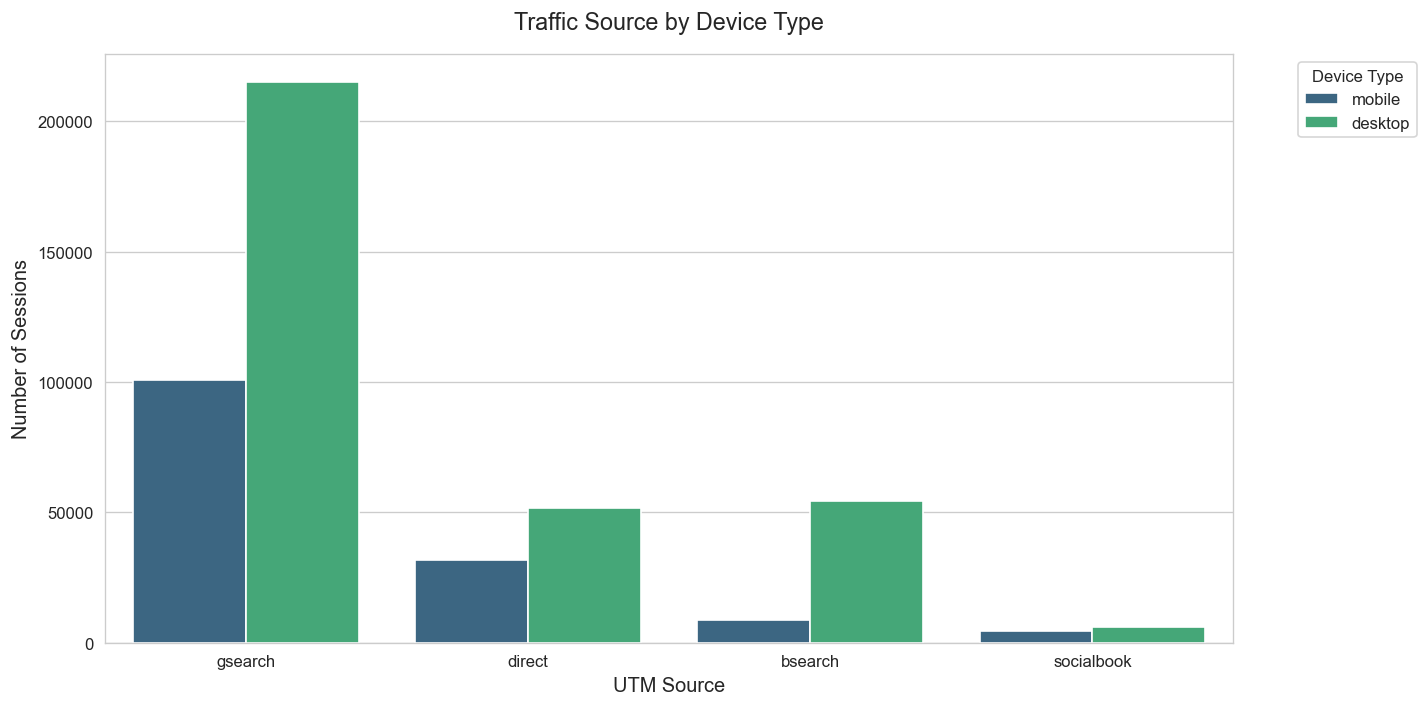

In [63]:
sns.set_style("whitegrid")
sns.countplot(data=website_sessions, x='utm_source', hue='device_type', palette='viridis')
plt.title('Traffic Source by Device Type', fontsize=14, pad=15)
plt.xlabel('UTM Source', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)
plt.legend(title='Device Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../reports/figures/source_by_device.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Nguồn Truy cập theo Loại Thiết bị (Traffic Source by Device Type)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột ghép (Grouped Bar chart).
* **Tiêu đề:** Traffic Source by Device Type (Nguồn truy cập phân bổ theo Loại thiết bị).
* **Trục tung (Y-axis):** Number of Sessions - Số lượng phiên truy cập.
* **Trục hoành (X-axis):** UTM Source - Các nguồn truy cập chính (gsearch, direct, bsearch, socialbook).
* **Chú giải (Legend):** Thể hiện 2 nhóm thiết bị là `mobile` (Màu xanh dương đậm) và `desktop` (Màu xanh lá).

---

## 2. Bảng Số liệu Ước lượng

Dựa vào các mốc trên trục tung, chúng ta có thể ước lượng phân bổ lưu lượng như sau:

| Nguồn (UTM Source) | Desktop (Phiên) | Mobile (Phiên) | Tương quan Desktop vs Mobile |
| :--- | :--- | :--- | :--- |
| **gsearch** | ~ 215,000 | ~ 100,000 | Desktop cao hơn gấp đôi |
| **direct** | ~ 55,000 | ~ 30,000 | Desktop cao gần gấp đôi |
| **bsearch** | ~ 55,000 | ~ 8,000 | Desktop áp đảo hoàn toàn (gấp ~7 lần) |
| **socialbook** | ~ 5,000 | ~ 5,000 | Khá cân bằng, chênh lệch không đáng kể |

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Desktop chiếm ưu thế trên các kênh chủ lực
* Xu hướng chuộng Desktop (đã phân tích ở biểu đồ Pie Chart trước đó) được thể hiện đồng nhất trên cả hai kênh mang lại traffic lớn nhất là `gsearch` và `direct`. 
* Điều này củng cố giả thuyết rằng khách hàng thường tìm kiếm thông qua Google hoặc gõ trực tiếp URL khi họ đang sử dụng máy tính làm việc.

### Sự bất đối xứng kỳ lạ của "bsearch" (Bing Search)
* Kênh `bsearch` có tỷ lệ chênh lệch giữa Desktop và Mobile lớn nhất. Lượng truy cập từ Desktop cao gấp khoảng 7 lần so với Mobile.
* **Giải thích:** Điều này hoàn toàn hợp lý với hành vi người dùng thực tế. Bing là công cụ tìm kiếm mặc định trên trình duyệt Edge của hệ điều hành Windows (Desktop). Rất hiếm người dùng tải ứng dụng Bing hoặc dùng Bing làm công cụ tìm kiếm mặc định trên điện thoại di động (Mobile).

### Kênh "socialbook" không thể hiện đặc tính Mobile
* Thông thường, traffic từ mạng xã hội (Social Media) sẽ nghiêng hẳn về thiết bị Mobile vì người dùng chủ yếu lướt mạng xã hội trên điện thoại. 
* Tuy nhiên, lượng traffic từ `socialbook` trong biểu đồ này lại rất thấp và chia đều cho cả Desktop lẫn Mobile. Điều này cho thấy chiến dịch social hiện tại không chạm được đến tệp người dùng lướt điện thoại, hoặc liên kết chia sẻ không được tối ưu để click trên nền tảng di động.

---

## 4. Đề xuất Chiến lược (Recommendations)

1. **Tối ưu hóa chiến dịch quảng cáo trên Bing (bsearch):**
   * Do đặc thù traffic của Bing gần như 100% đến từ Desktop, hãy điều chỉnh giá thầu (Bid adjustment) trên nền tảng quảng cáo của Bing: Tăng giá thầu cho thiết bị máy tính và giảm hoặc tắt luôn quảng cáo hiển thị trên thiết bị di động để tránh lãng phí ngân sách.

2. **Cá nhân hóa theo thiết bị cho kênh Google (gsearch):**
   * Thiết kế hai luồng trải nghiệm (Landing pages) khác nhau. Người dùng nhấp vào link `gsearch` từ Mobile thường có mục đích tìm kiếm nhanh hoặc xem lướt qua; hãy hiển thị thông tin ngắn gọn, nút gọi hoặc chat trực tiếp.
   * Người dùng từ Desktop có xu hướng xem xét kỹ lưỡng hơn; hãy cung cấp hình ảnh sản phẩm chi tiết, đánh giá và các bài blog phân tích dài.

3. **Điều tra chiến dịch Mạng xã hội:**
   * Cần xem xét lại cách bài đăng mạng xã hội đang được hiển thị trên các ứng dụng di động. Nếu traffic từ Mobile quá thấp, có thể liên kết (link) đang gặp lỗi hiển thị (broken link) hoặc giao diện trang đích khi mở bằng trình duyệt nội bộ của ứng dụng mạng xã hội bị vỡ layout, khiến người dùng thoát ra ngay lập tức.

# Website_pageviews 

In [67]:
display(website_pageviews.head())

,website_pageview_id,created_at,website_session_id,pageview_url,year,month,day,hour,day_name
0,1,2012-03-19 08:04:16,1,/home,2012,3,19,8,Monday
1,2,2012-03-19 08:16:49,2,/home,2012,3,19,8,Monday
2,3,2012-03-19 08:26:55,3,/home,2012,3,19,8,Monday
3,4,2012-03-19 08:37:33,4,/home,2012,3,19,8,Monday
4,5,2012-03-19 09:00:55,5,/home,2012,3,19,9,Monday


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_17820\855928659.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pages_dataset, y='pageview_url', x='view_count', palette='viridis')


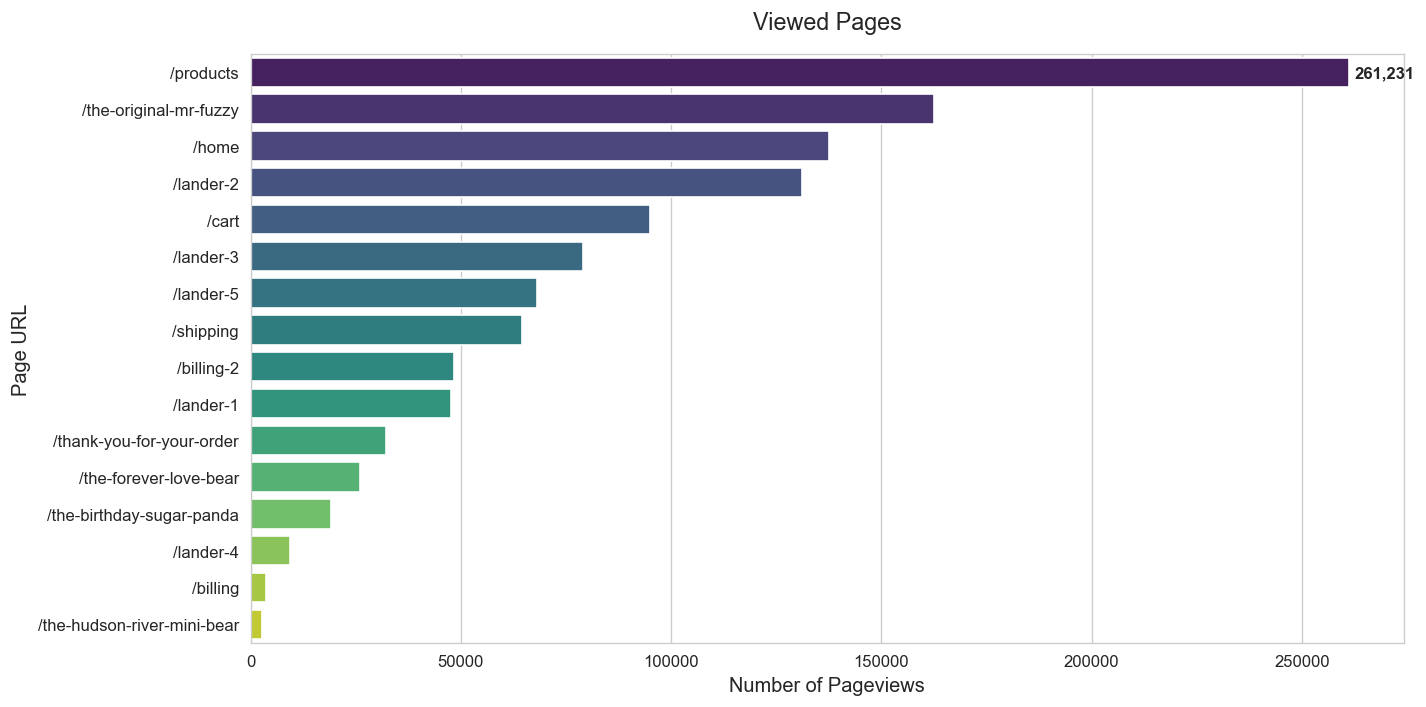

In [72]:

top_pages_dataset = website_pageviews['pageview_url'].value_counts().reset_index()
top_pages_dataset.columns = ['pageview_url', 'view_count']
sns.set_style("whitegrid")
sns.barplot(data=top_pages_dataset, y='pageview_url', x='view_count', palette='viridis')
ax = plt.gca()
ax.bar_label(ax.containers[0], padding=3, fontweight='bold', fmt='{:,.0f}')
plt.title('Viewed Pages', fontsize=14, pad=15)
plt.xlabel('Number of Pageviews', fontsize=12)
plt.ylabel('Page URL', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/top_pageviews.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Lượt xem trang (Viewed Pages)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột ngang (Horizontal Bar chart).
* **Tiêu đề:** Viewed Pages (Các trang được xem nhiều nhất).
* **Trục tung (Y-axis):** Page URL - Đường dẫn của các trang trên website (bao gồm trang sản phẩm, trang đích, và các bước thanh toán).
* **Trục hoành (X-axis):** Number of Pageviews - Số lượng lượt xem trang.

---

## 2. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Trang Danh mục là cổng vào chính (Top Entry Point)
* URL `/products` dẫn đầu tuyệt đối với **261,231 lượt xem**. Điều này cho thấy phần lớn khách hàng thích vào trang danh mục tổng hợp để lướt xem nhiều sản phẩm cùng lúc trước khi quyết định click vào xem chi tiết một sản phẩm cụ thể.

### Sự tương quan hoàn hảo với Doanh thu (Revenue Correlation)
Lượt xem của các trang sản phẩm phản ánh chính xác 100% thứ hạng doanh thu ở các biểu đồ trước:
1. `/the-original-mr-fuzzy` (ID 1) đứng thứ hai toàn trang với hơn 160,000 pageviews (Sản phẩm "Gà đẻ trứng vàng").
2. `/the-forever-love-bear` (ID 2) ~ 25,000 pageviews.
3. `/the-birthday-sugar-panda` (ID 3) ~ 20,000 pageviews.
4. `/the-hudson-river-mini-bear` (ID 4) có pageviews thấp nhất, nằm bét bảng.
* **Đánh giá:** Traffic chính là động lực tạo ra doanh thu. Sự chênh lệch doanh thu không hẳn do sản phẩm khác dở hơn, mà do chúng không nhận được đủ lượng truy cập.

### Dấu ấn của Thử nghiệm A/B Testing (Landing Pages)
* Website đang chạy rất nhiều trang đích khác nhau (từ `/lander-1` đến `/lander-5`).
* Trong đó, `/lander-2` nhận được lượng traffic khổng lồ (~130,000 lượt xem), chỉ đứng sau `/products`, `/mr-fuzzy` và `/home`. 
* **Đánh giá:** Rất có thể `/lander-2` đang được cấu hình làm trang đích chính cho các chiến dịch quảng cáo trả phí (ví dụ: gsearch ở biểu đồ trước). Các `lander` khác có traffic thấp hơn nhiều, cho thấy doanh nghiệp đang liên tục test các giao diện mới để tối ưu tỷ lệ chuyển đổi.

### Phân tích Phễu Thanh toán (Checkout Funnel Drop-off)
Chúng ta có thể hình dung rõ tỷ lệ rớt khách (Drop-off rate) thông qua hành trình thanh toán:
1. **Thêm vào giỏ (`/cart`):** ~ 95,000 lượt.
2. **Điền thông tin giao hàng (`/shipping`):** ~ 65,000 lượt (Rớt khoảng ~30% từ bước Cart).
3. **Thanh toán (`/billing-2`):** ~ 48,000 lượt (Rớt thêm ~26% từ bước Shipping).
4. **Hoàn tất đơn hàng (`/thank-you-for-your-order`):** ~ 30,000 lượt (Rớt thêm ~37% từ bước Billing).
* **Điểm chú ý:** Con số ~30,000 lượt xem trang cảm ơn (tương đương 30,000 đơn hàng thành công) **rất khớp** với tổng số lượng đơn hàng (32,313 đơn) mà chúng ta đã phân tích ở biểu đồ phân phối đơn hàng (Countplot) trước đó! 
* Ngoài ra, trang `/billing` cũ có lượng traffic cực kỳ thấp (vài nghìn), cho thấy công ty đã chuyển hướng thành công người dùng sang trang thanh toán phiên bản mới là `/billing-2`.

---

## 3. Đề xuất Chiến lược (Recommendations)

1. **Điều hướng Traffic để cứu các sản phẩm nhóm dưới:**
   * Vì `/products` đang có lượng traffic cực lớn (hơn 260k), hãy thay đổi thuật toán sắp xếp (sorting) trên trang này. Đẩy hình ảnh của `Forever Love Bear` hoặc `Hudson River Mini bear` lên các vị trí trung tâm, bắt mắt nhất ở đầu trang để kéo traffic từ `/products` chảy sang các sản phẩm này.

2. **Tối ưu hóa Phễu Thanh toán (CRO - Conversion Rate Optimization):**
   * Mức sụt giảm từ `/billing-2` (48k) xuống trang hoàn tất đơn hàng (30k) là một sự lãng phí lớn (khoảng 18,000 khách hàng đã đến bước cuối cùng nhưng không trả tiền).
   * Cần kiểm tra lại trang `/billing-2`: Cổng thanh toán có bị lỗi không? Có phát sinh thêm phí ẩn (hidden fees) làm khách hàng bỏ cuộc không? Hình thức thanh toán có bị hạn chế không?
   * Triển khai ngay chiến dịch **Cart Abandonment Email** (Gửi email nhắc nhở giỏ hàng bị bỏ quên) cho những khách hàng đã điền email ở bước `/shipping` nhưng không hoàn tất `/billing-2`.

3. **Chốt kết quả A/B Test của Landing Page:**
   * Cần kết hợp dữ liệu này với tỷ lệ chuyển đổi (Conversion Rate) của từng `lander`. Nếu `/lander-2` đang có traffic cao nhất VÀ tỷ lệ chuyển đổi tốt nhất, hãy dồn toàn bộ ngân sách quảng cáo vào nó và loại bỏ các phiên bản kém hiệu quả.

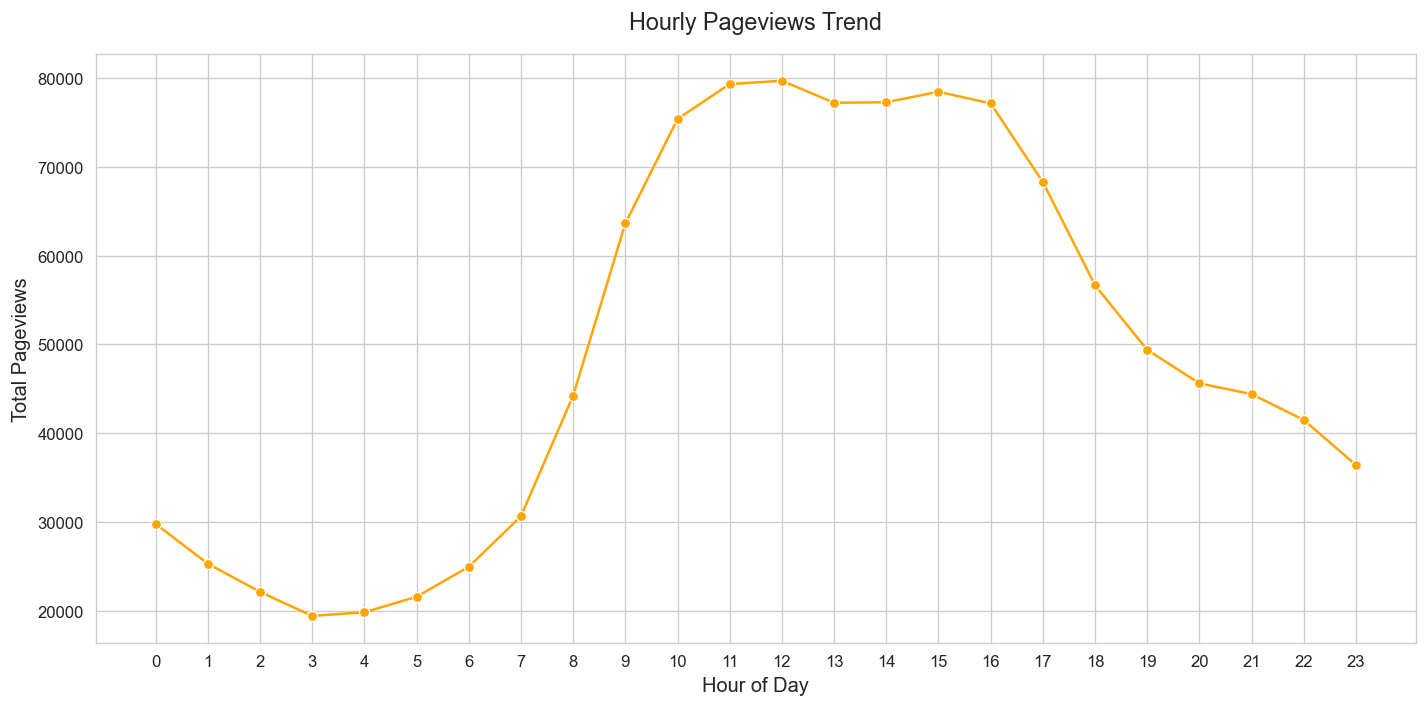

In [81]:
hourly_pageviews_dataset = website_pageviews.groupby('hour')['website_pageview_id'].count().reset_index()
sns.set_style("whitegrid")
sns.lineplot(data=hourly_pageviews_dataset, x='hour', y='website_pageview_id', marker='o', color='orange')
plt.title('Hourly Pageviews Trend', fontsize=14, pad=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Total Pageviews', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../reports/figures/Hour of Day_pageviews.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Xu hướng Lượt xem trang theo Giờ (Hourly Pageviews Trend)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ đường (Line chart) thể hiện chuỗi thời gian trong ngày.
* **Tiêu đề:** Hourly Pageviews Trend (Xu hướng Lượt xem trang theo từng giờ).
* **Trục tung (Y-axis):** Total Pageviews - Tổng số lượt xem trang (từ mốc 20,000 đến 80,000).
* **Trục hoành (X-axis):** Hour of Day - Các khung giờ trong ngày (từ 0h đến 23h).

---

## 2. Các Quan sát Chính (Key Observations)

* **Giờ "thấp điểm" (Trough):** Lượng truy cập chạm đáy vào rạng sáng, cụ thể là khung **3:00 - 4:00 sáng**, với chỉ khoảng **20,000 lượt xem**.
* **Giai đoạn tăng tốc:** Bắt đầu từ 7:00 sáng, lượng truy cập tăng vọt theo phương thẳng đứng và kéo dài đà tăng trưởng cho đến 10:00 sáng.
* **Khung giờ "vàng" (Peak / Prime time):** Website duy trì lượng traffic khổng lồ và ổn định trên mức 75,000 lượt xem từ **11:00 trưa đến 16:00 chiều (4:00 PM)**. Đỉnh điểm tuyệt đối rơi vào khoảng 11:00 - 12:00 trưa (đạt mốc ~80,000).
* **Giai đoạn thoái trào:** Từ 17:00 (5:00 PM) trở đi, biểu đồ bắt đầu dốc xuống rõ rệt. Lượng pageviews giảm dần đều cho đến nửa đêm.

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Bằng chứng rõ nét của hành vi "Mua sắm công sở" (Office-hour Browsing)
* Biểu đồ này hoàn toàn khớp với Insight từ biểu đồ *Sessions by Device Type* (Desktop chiếm 69.2%). Khách hàng của doanh nghiệp chủ yếu lướt xem và mua sản phẩm trong **giờ hành chính** (từ 9h sáng đến 5h chiều).
* Họ có xu hướng dạo quanh website mạnh nhất vào trước và trong giờ nghỉ trưa (11h - 12h), và duy trì việc duyệt web song song với giờ làm việc buổi chiều (đến 16h).
* Ngay khi giờ tan tầm bắt đầu (17:00), lượng truy cập lập tức sụt giảm và không có dấu hiệu phục hồi vào buổi tối (thời điểm người dùng thường chuyển sang dùng Mobile và xem các kênh giải trí, mạng xã hội).

---

## 4. Đề xuất & Định hướng Hành động (Recommendations)

1. **Tối ưu Lịch chạy Quảng cáo (Ad Scheduling / Dayparting):**
   * Tập trung tối đa ngân sách và tăng giá thầu (Bid adjustments) cho các chiến dịch Google Search vào khung giờ từ **8:00 sáng đến 16:00 chiều**.
   * Giảm mạnh hoặc tắt hẳn quảng cáo từ sau 23:00 đêm đến 6:00 sáng hôm sau để tránh lãng phí ngân sách vào những lượt click có tỷ lệ chuyển đổi (Conversion Rate) thấp.

2. **Chiến lược Gửi Email / Push Notification:**
   * Lên lịch gửi các chiến dịch Email Marketing hoặc thông báo khuyến mãi (Push Notification) vào lúc **9:00 - 10:00 sáng**. Đây là lúc người dùng bắt đầu "vào guồng" duyệt web; việc gửi thông điệp lúc này sẽ đón đúng "cơn sóng" traffic đang tăng mạnh lên đỉnh.

3. **Lên lịch Vận hành & Bảo trì Hệ thống (IT Operations):**
   * Lịch trình lý tưởng nhất để bộ phận IT thực hiện bảo trì server, cập nhật tính năng mới (Deploy) hoặc sao lưu dữ liệu (Backup) là vào **khung 3:00 - 4:00 sáng**. Đây là thời điểm hệ thống ít chịu tải nhất, giúp giảm thiểu tối đa rủi ro gián đoạn trải nghiệm của khách hàng.

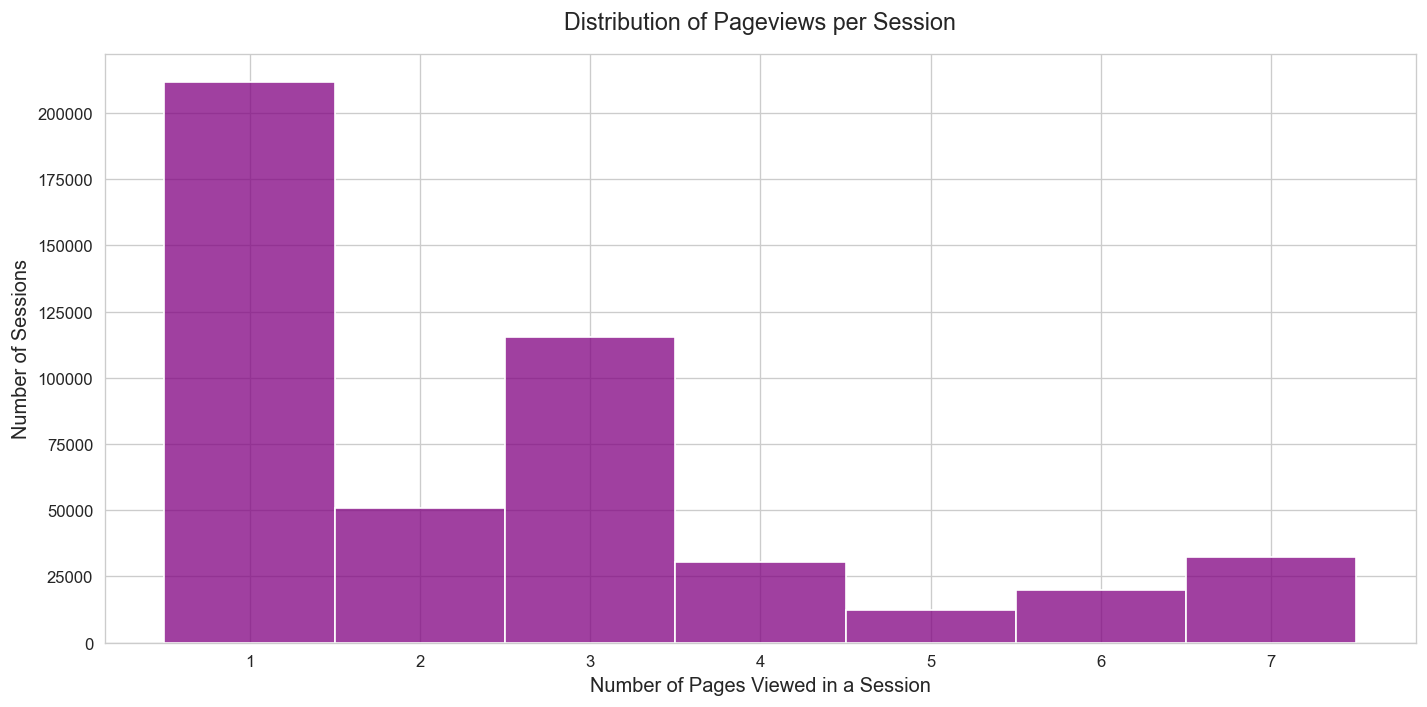

In [84]:

pages_per_session_dataset = website_pageviews.groupby('website_session_id')['website_pageview_id'].count().reset_index()
pages_per_session_dataset.columns = ['website_session_id', 'page_count']
sns.set_style("whitegrid")
sns.histplot(data=pages_per_session_dataset, x='page_count', discrete=True, color='purple')
plt.title('Distribution of Pageviews per Session', fontsize=14, pad=15)
plt.xlabel('Number of Pages Viewed in a Session', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)
plt.xticks(range(1, pages_per_session_dataset['page_count'].max() + 1))
plt.tight_layout()
plt.savefig('../reports/figures/pages_per_session.png', dpi=300, bbox_inches='tight')
plt.show()

# Báo cáo Phân tích Phân phối Lượt xem trang trên mỗi Phiên (Distribution of Pageviews per Session)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ phân phối / Biểu đồ cột tần suất (Histogram / Bar chart).
* **Tiêu đề:** Distribution of Items Purchased per Order (Lưu ý: Tiêu đề biểu đồ hiển thị trên hình là *Distribution of Pageviews per Session* - Phân phối số lượt xem trang trong một phiên).
* **Trục tung (Y-axis):** Number of Sessions - Số lượng phiên truy cập (dao động từ mốc 0 đến hơn 200,000).
* **Trục hoành (X-axis):** Number of Pages Viewed in a Session - Số lượng trang được xem trong một phiên truy cập (từ 1 đến 7 trang).

---

## 2. Số liệu Ước lượng & Phân tích cấu trúc

Dựa vào độ cao của các cột dữ liệu, chúng ta có thể ước lượng số lượng phiên truy cập như sau:

| Số trang được xem / Phiên | Số lượng Phiên (Ước lượng) | Đặc điểm hành vi |
| :---: | :--- | :--- |
| **1** | ~ 210,000 | Thoát ngay (Bounce) hoặc xem lướt |
| **2** | ~ 50,000 | Xem thêm 1 trang |
| **3** | ~ 115,000 | Đột biến (Nhóm quan tâm sâu) |
| **4** | ~ 30,000 | Đi sâu vào phễu |
| **5** | ~ 12,000 | Đi sâu vào phễu |
| **6** | ~ 19,000 | Gần chạm đích thanh toán |
| **7** | ~ 32,000 | Hoàn tất hành trình (Mua hàng) |

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Tỷ lệ Bounce Rate (Thoát trang ngay lập tức) rất cao
* Cột **1 trang/phiên** chiếm số lượng áp đảo tuyệt đối với hơn 210,000 phiên. Điều này chứng tỏ một bộ phận lớn người dùng nhấp vào trang web (có thể từ các chiến dịch `gsearch` bùng nổ ở biểu đồ trước) nhưng rời đi ngay lập tức mà không bấm thêm bất kỳ liên kết nào khác.
* **Đánh giá:** Trang đích (Landing page) có thể chưa giữ chân khách hàng đủ tốt, hoặc nội dung quảng cáo chưa hoàn toàn đồng nhất với kỳ vọng của người dùng.

### Điểm kỳ lạ: Sự bùng nổ ở mốc "3 trang/phiên" và "7 trang/phiên"
Biểu đồ phân phối này không giảm dần đều theo dạng đồ thị phân phối chuẩn, mà xuất hiện các "bước nhảy" (peaks) bất thường rất thú vị:
* **Đỉnh nhỏ tại mốc 3 trang:** Lượng khách xem đúng 3 trang (~115k) cao gấp đôi lượng khách xem 2 trang. Đây thường là luồng: `Vào trang đích (1) -> Bấm xem danh mục sản phẩm (2) -> Click xem chi tiết 1 sản phẩm cụ thể (3) rồi thoát`. Nhóm này có sự hứng thú nhất định với sản phẩm.
* **Đỉnh nhỏ tại mốc 7 trang:** Cột 7 trang (~32k) có xu hướng tăng nhẹ trở lại so với các mốc 5, 6 trang. Con số ~32,000 phiên này **trùng khớp hoàn toàn** với số lượng đơn hàng thành công (~32,313) và lượt xem trang `/thank-you-for-your-order` (~30,000) ở các biểu đồ trước! 
* **Kết luận hệ thống:** Để một khách hàng hoàn tất việc mua 1-2 món gấu bông trên website này, họ cần trải qua một hành trình chuẩn xác gồm đúng **7 lượt xem trang** (ví dụ: `Home -> Products -> Product Detail -> Cart -> Shipping -> Billing -> Thank you`).

---

## 4. Đề xuất Chiến lược (Recommendations)

1. **Cải thiện trang đích để giảm tỷ lệ 1 trang/phiên:**
   * Vì tệp khách hàng thoát ngay sau 1 trang là quá lớn (>210k), cần tối ưu hóa ngay tốc độ tải trang và thiết kế các nút kêu gọi hành động (CTA) rõ ràng hơn trên các trang đích chủ lực như `/lander-2`.
   * Thực hiện khảo sát hoặc kiểm tra bản đồ nhiệt (Heatmap) để biết lý do tại sao khách hàng rời đi sớm.

2. **Bám đuổi nhóm khách hàng "3 trang/phiên":**
   * Nhóm xem 3 trang là nhóm đã xem chi tiết sản phẩm nhưng chưa bấm "Thêm vào giỏ hàng" (`/cart`). 
   * Hãy triển khai các chiến dịch **Remarketing (Tiếp thị lại)** trên Google/Mạng xã hội nhắm thẳng vào tệp này bằng cách tặng mã giảm giá ngắn hạn hoặc hiển thị lại đúng sản phẩm họ đã xem để thúc đẩy họ quay lại và bước tiếp vào phễu thanh toán (đạt mốc 7 trang).

3. **Rút ngắn hành trình mua hàng (Tối ưu phễu):**
   * Nếu hành trình mua sắm bắt buộc phải qua 7 trang, hãy tìm cách rút ngắn nó xuống còn 5 hoặc 6 trang nhằm giảm thiểu rủi ro rớt khách giữa đường. 
   * **Giải pháp:** Tích hợp tính năng "Mua ngay" (Buy Now) tại trang chi tiết sản phẩm để bỏ qua bước vào trang `/cart` truyền thống, đưa thẳng khách hàng tới trang điền thông tin `/shipping`.